In [4]:
# ==========================================
# ANALYSIS #2: SPECIAL TEAMS "FREEZE"
# CELL 1: THE OVER-PASSING PIVOT
# ==========================================

import time
import pandas as pd
from datetime import datetime
from nhlpy import NHLClient

# Initialize Client
client = NHLClient()

TEAM_ABBR = "DET"
SEASON = "20252026"
MID_SEASON_BREAK = datetime.strptime("2026-02-06", "%Y-%m-%d")

# The 2025-26 Detroit Primary Power Play Core
PP_UNIT_CORE = ["Larkin", "DeBrincat", "Raymond", "Seider", "Compher", "Kane"]

# Fetch schedule
schedule_response = client.schedule.team_season_schedule(team_abbr=TEAM_ABBR, season=SEASON)
games_list = schedule_response.get('games', [])

pp_telemetry = []
print(f"[Process] Analyzing {len(games_list)} games for Over-Passing metrics...")

for index, game in enumerate(games_list):
    game_id = str(game.get('id'))
    if game_id[4:6] != '02': continue 
    
    game_date_str = game.get('gameDate')
    game_date = datetime.strptime(game_date_str, "%Y-%m-%d")
    season_phase = "Early" if game_date < MID_SEASON_BREAK else "Late"
    
    try:
        time.sleep(0.7) 
        data = client.game_center.boxscore(game_id=game_id)
        
        player_data_root = data.get('playerByGameStats', {})
        is_away = data.get('awayTeam', {}).get('abbrev') == TEAM_ABBR
        side_key = 'awayTeam' if is_away else 'homeTeam'
        
        detroit_players = player_data_root.get(side_key, {})
        skaters = detroit_players.get('forwards', []) + detroit_players.get('defense', [])

        for p in skaters:
            full_name = p.get('name', {}).get('default', '')
            last_name = full_name.split(' ')[-1] if full_name else ''
            
            if last_name in PP_UNIT_CORE:
                # Extract TOI (Total Time on Ice)
                toi_str = str(p.get('toi', '00:00')).strip()
                if ':' in toi_str:
                    m, s = map(int, toi_str.split(':'))
                    toi_dec = m + (s / 60.0)
                else:
                    toi_dec = 0.0
                
                if toi_dec > 0:
                    pp_telemetry.append({
                        'season_phase': season_phase,
                        'toi': toi_dec,
                        'sog': p.get('sog', 0),
                        'assists': p.get('assists', 0),
                        'giveaways': p.get('giveaways', 0),
                        'pp_goals': p.get('powerPlayGoals', 0)
                    })
                    
    except Exception as e:
        continue

# --- AGGREGATION & RATIO CALCULATION ---
df_pp = pd.DataFrame(pp_telemetry)

if not df_pp.empty:
    print(f"\n[Success] Captured {len(df_pp)} PP core appearances.")
    
    # Sum up all raw stats by Season Phase
    summary_raw = df_pp.groupby('season_phase')[['toi', 'sog', 'assists', 'giveaways', 'pp_goals']].sum()
    
    # Calculate our advanced analytical ratios
    final_summary = pd.DataFrame(index=summary_raw.index)
    final_summary['total_pp_goals'] = summary_raw['pp_goals']
    
    # Over-passing metric: How many assists are generated per shot taken?
    final_summary['pass_to_shoot_ratio'] = summary_raw['assists'] / summary_raw['sog']
    
    # Pressure mistakes: Giveaways per 60 minutes of ice time
    final_summary['giveaways_per_60'] = (summary_raw['giveaways'] / summary_raw['toi']) * 60
    
    # Sort order
    final_summary = final_summary.reindex(['Early', 'Late'])
    
    display(final_summary)
else:
    print("\n[Error] No data captured.")

[Process] Analyzing 90 games for Over-Passing metrics...

[Success] Captured 467 PP core appearances.


,total_pp_goals,pass_to_shoot_ratio,giveaways_per_60
season_phase,,,
Early,28,0.200252,2.872285
Late,13,0.222543,2.979584


[Success] Triptych visualization saved as 'special_teams_freeze.png'


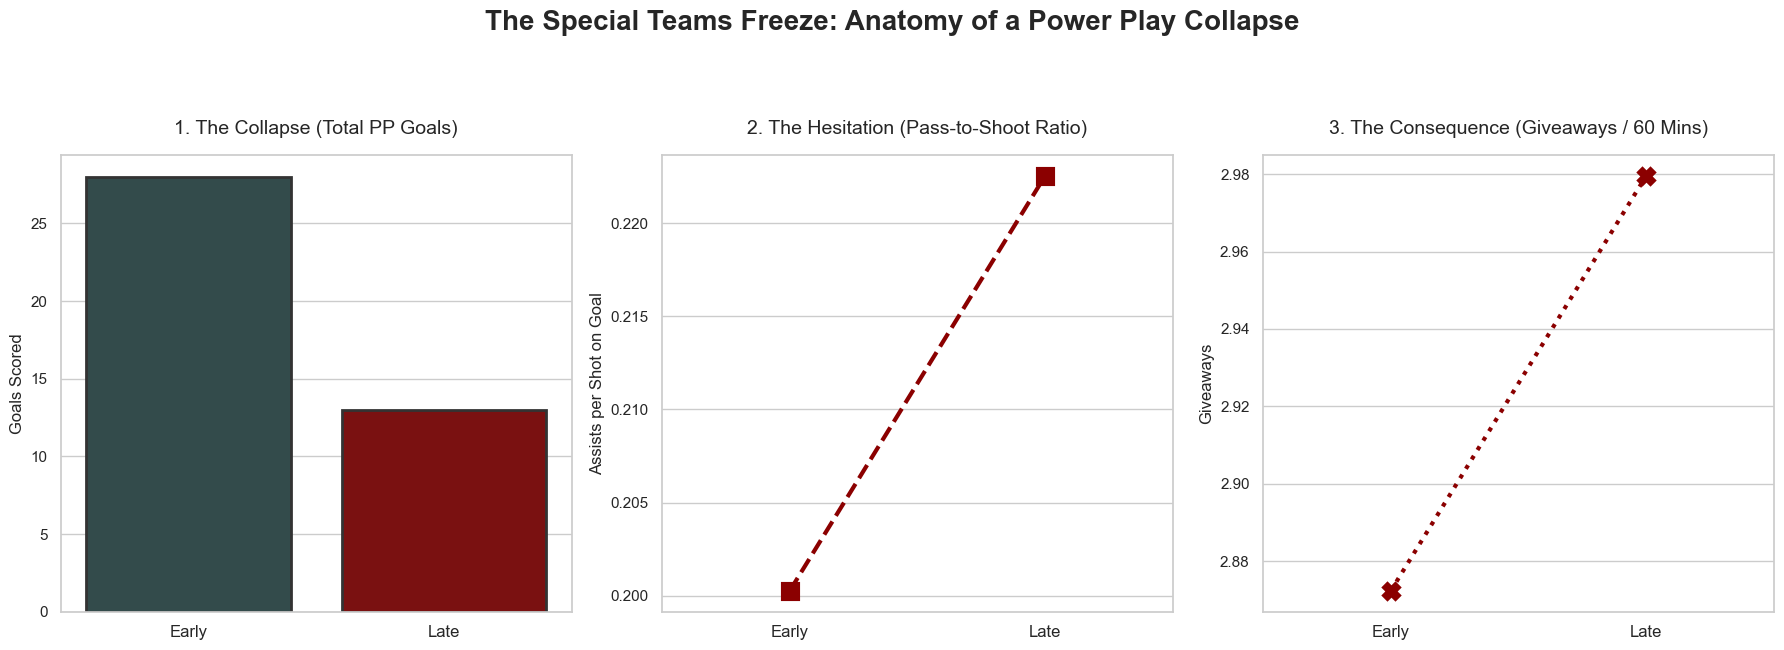

In [8]:
# ==========================================
# ANALYSIS #2: SPECIAL TEAMS "FREEZE"
# CELL 2: THE TRIPTYCH DASHBOARD (FUTURE-PROOFED)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic
sns.set_theme(style="whitegrid")

# Create a 1x3 grid for our three distinct metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('The Special Teams Freeze: Anatomy of a Power Play Collapse', 
             fontsize=20, fontweight='bold', y=1.08)

# Prepare data for plotting
df_viz = final_summary.reset_index()

# Custom Color Palette (Slate for Early/Stable, Dark Red for Late/Panic)
phase_colors = {"Early": "#2F4F4F", "Late": "#8B0000"}

# --- PANEL 1: The Production Drop (Bar Chart) ---
# FIX: Assigned 'season_phase' to hue and disabled legend to resolve FutureWarning
sns.barplot(
    data=df_viz, x='season_phase', y='total_pp_goals', hue='season_phase',
    palette=phase_colors, ax=axes[0], edgecolor=".2", linewidth=2, legend=False
)
axes[0].set_title('1. The Collapse (Total PP Goals)', fontsize=14, pad=15)
axes[0].set_ylabel('Goals Scored', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', labelsize=12)

# --- PANEL 2: The Hesitation (Point Plot) ---
sns.pointplot(
    data=df_viz, x='season_phase', y='pass_to_shoot_ratio', 
    color="#8B0000", markers='s', linestyles='--', linewidth=3, markersize=12, ax=axes[1]
)
axes[1].set_title('2. The Hesitation (Pass-to-Shoot Ratio)', fontsize=14, pad=15)
axes[1].set_ylabel('Assists per Shot on Goal', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', labelsize=12)

# --- PANEL 3: The Consequence (Point Plot) ---
sns.pointplot(
    data=df_viz, x='season_phase', y='giveaways_per_60', 
    color="#8B0000", markers='X', linestyles=':', linewidth=3, markersize=12, ax=axes[2]
)
axes[2].set_title('3. The Consequence (Giveaways / 60 Mins)', fontsize=14, pad=15)
axes[2].set_ylabel('Giveaways', fontsize=12)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', labelsize=12)

# Clean up layout and save
plt.tight_layout()
plt.savefig('special_teams_freeze.png', bbox_inches='tight', dpi=300)
print("[Success] Triptych visualization saved as 'special_teams_freeze.png'")
plt.show()